In [25]:
# Imports
import pandas as pd
import numpy as np

# Plotting Imports
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocessing Imports
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder

# Modelling imports
from sklearn.cluster import AgglomerativeClustering
from sklearn_extra.cluster import KMedoids

In [14]:
# Importing data
student_data = pd.read_csv('student_data_unsupervised_learning.csv')
student_data.head(10)

,student_id,"How many minutes is your typical commute (one way)? *this includes walking, biking, driving, or public transit time",How many hours per week do you typically work?,How many credits are you enrolled in this semester?,How many lab courses are you enrolled in this semester?
0,1,0-15 mins,21-30,6,1
1,2,0-15 mins,11-20,18,2
2,5,0-15 mins,0,15,2
3,6,16-30 mins,11-20,16,1
4,7,0-15 mins,1-10,16,2
5,9,31-45 mins,11-20,15,2
6,12,0-15 mins,0,18,2
7,13,0-15 mins,0,13,2
8,15,16-30 mins,1-10,17,1
9,20,16-30 mins,0,17,0


In [15]:
# Removing rows with empty columns

student_data = student_data.dropna()

In [16]:
# Renaming columns 
student_data = student_data.rename(
    columns = {student_data.columns[1]: 'commuting_minutes', 
               student_data.columns[2]: 'work_hours',
               student_data.columns[3]: 'credits', 
               student_data.columns[4]: 'labs'})

student_data.head()

,student_id,commuting_minutes,work_hours,credits,labs
0,1,0-15 mins,21-30,6,1
1,2,0-15 mins,11-20,18,2
2,5,0-15 mins,0,15,2
3,6,16-30 mins,11-20,16,1
4,7,0-15 mins,1-10,16,2


In [7]:
print(student_data['labs'].value_counts())

labs
0            70
2            61
1            49
3 or more     5
Name: count, dtype: int64


In [8]:
# Preprocessing

commuting_order = ['0-15 mins', '16-30 mins', '31-45 mins', '46-60 mins', '> Hour']
work_hours_order = ['0', '1-10', '11-20', '21-30', '31-40']
labs_order = ['0', '1', '2', '3 or more']

labels = ['commuting_minutes', 'work_hours', 'labs']

for col in labels:
    student_data[col] = student_data[col].astype(str).str.strip()

student_data.head()

preprocessor = make_column_transformer(
    (OrdinalEncoder(categories = [commuting_order, work_hours_order, labs_order]), labels),
    (StandardScaler(), ['credits']),
    remainder = 'passthrough'
)

encoded_variables = preprocessor.fit_transform(student_data)

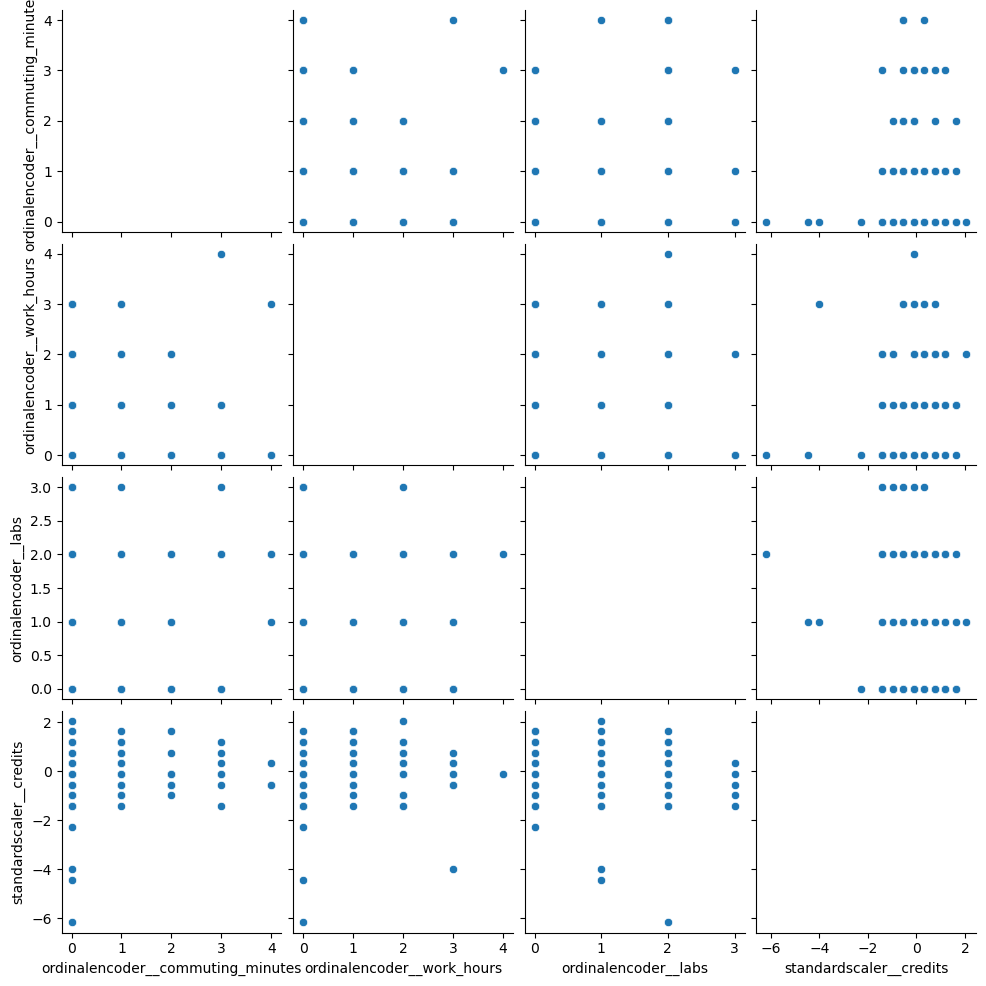

In [24]:
# Visualizing variables to pick which unsupervised learning algorithm is best fit

columns = preprocessor.get_feature_names_out() # First converting preprocessed values into a dataframe for plotting
df_encoded_variables = pd.DataFrame(encoded_variables, columns = columns)

variables =  ['ordinalencoder__commuting_minutes', 'ordinalencoder__work_hours', 'ordinalencoder__labs', 'standardscaler__credits']
sns.pairplot(df_encoded_variables[variables], diag_kind = 'scatter')
plt.show() # Plot shows a good number of oval shaped data so 